# Домашнее задание №4: исследование линейной регрессии
**Цель задания** — провести полный цикл построения модели машинного обучения: взять данные, провести предобработку и разведочный анализ (EDA),
поработать с признаками, обучить модель (или модели) линейной регрессии, сравнить результаты и сделать обоснованные выводы о качестве
полученного решения.
**Задача** — написать код и сопроводить его текстовыми комментариями так, чтобы работа читалась как небольшое исследование, а не просто набор ячеек
с кодом. В ходе работы вы должны дать развернутые ответы на ряд ключевых вопросов (см. ниже)

**Columns:**

Id: Уникальный идентификатор для каждой записи об автомобиле.

Model: Название модели Toyota Corolla.

Price: Цена продажи подержанного автомобиля.

Age_08_04: Возраст автомобиля в месяцах по состоянию на август 2004 года.

Mfg_Month: Месяц производства автомобиля.

Mfg_Year: Год производства автомобиля.

KM: Количество километров, пройденных автомобилем.

Fuel_type: Тип топлива, используемого автомобилем (например, бензин, дизельное топливо).

HP: Лошадиные силы, показатель мощности двигателя.

Met_Color: Двоичный индикатор для металлизированной краски (0 = Нет, 1 = Да).

Color: Цвет кузова автомобиля.
Automatic: Двоичный индикатор для автоматической коробки передач (0 = Нет, 1 = Да).

CC: Объем двигателя в кубических сантиметрах.

Doors: Количество дверей автомобиля.
Cylinders: Количество цилиндров в двигателе.

Gears: Количество передач в трансмиссии.
Quarterly: Квартальный налог на автомобиль.

Weight: Вес автомобиля.

Mfr_Guarantee: Двоичный индикатор гарантии производителя (0 = Нет, 1 = Да).

BOVAG_Guarantee: Двоичный индикатор гарантии BOVAG (0 = Нет, 1 = Да).

Guarantee_Period: Срок гарантии в месяцах.

ABS: Двоичный индикатор антиблокировочной системы тормозов (0 = Нет, 1 = Да).

Airbag_1: Двоичный индикатор наличия подушки безопасности 1 (0 = Нет, 1 = Да).

Airbag_2: Двоичный индикатор наличия подушки безопасности 2 (0 = Нет, 1 = Да).

Airco: Двоичный индикатор кондиционера (0 = Нет, 1 = Да).

Automatic_airco: Двоичный индикатор автоматического кондиционирования воздуха (0 = Нет, 1 = Да).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
import warnings
import os
import kagglehub

#1. Загрузка Датасета

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vishakhdapat/price-of-used-toyota-corolla-cars")

print("Path to dataset files:", path)

fiels=os.listdir(path)
print("Файл в папаке:",fiels)

csv_file = [f for f in fiels if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

Using Colab cache for faster access to the 'price-of-used-toyota-corolla-cars' dataset.
Path to dataset files: /kaggle/input/price-of-used-toyota-corolla-cars
Файл в папаке: ['ToyotaCorolla.csv']


In [3]:
# Настройка отображения
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
sns.set(font_scale=1.2)

# 1. Загрузка данных
print("1. Загрузка данных...")
df = pd.read_csv(full_path)

1. Загрузка данных...


 # 2.Первичный анализ данных (EDA) и предобработка

In [4]:
df.head(7);

In [5]:
df.tail(7);

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


In [7]:
print("Количество записей:\n", df.count())
print("\nСтатистика:\n", df.describe())
print("\nПропуски:\n", df.isnull().sum())

Количество записей:
 Id                   1436
Model                1436
Price                1436
Age_08_04            1436
Mfg_Month            1436
Mfg_Year             1436
KM                   1436
Fuel_Type            1436
HP                   1436
Met_Color            1436
Color                1436
Automatic            1436
CC                   1436
Doors                1436
Cylinders            1436
Gears                1436
Quarterly_Tax        1436
Weight               1436
Mfr_Guarantee        1436
BOVAG_Guarantee      1436
Guarantee_Period     1436
ABS                  1436
Airbag_1             1436
Airbag_2             1436
Airco                1436
Automatic_airco      1436
Boardcomputer        1436
CD_Player            1436
Central_Lock         1436
Powered_Windows      1436
Power_Steering       1436
Radio                1436
Mistlamps            1436
Sport_Model          1436
Backseat_Divider     1436
Metallic_Rim         1436
Radio_cassette       1436
Parking_Assistant

In [8]:
print("\nСтатистика для категориальных данных:\n",df.describe(include='object'))
print("\nРазмерность датасета:\n",df.shape)


Статистика для категориальных данных:
                                                     Model Fuel_Type Color
count                                                1436      1436  1436
unique                                                319         3    10
top     TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-...    Petrol  Grey
freq                                                  109      1264   301

Размерность датасета:
 (1436, 39)


In [9]:
df.dtypes

,0
Id,int64
Model,object
Price,int64
Age_08_04,int64
Mfg_Month,int64
Mfg_Year,int64
KM,int64
Fuel_Type,object
HP,int64
Met_Color,int64


Обработала пропуски, посмотрела размерность

## Заполнение пропусков

In [10]:
#Удаление дубликатов
df.drop_duplicates()
#Удаление пропусков
df.dropna()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,0,2000,3,4,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,0,2000,3,4,5,210,1170,1,1,3,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,Blue,0,1300,3,4,5,69,1025,1,1,3,1,1,1,1,0,0,0,1,1,1,0,1,1,1,0,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,Grey,0,1300,3,4,5,69,1015,0,1,3,1,1,1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,Blue,0,1300,3,4,5,69,1015,0,1,3,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,Grey,0,1300,3,4,5,69,1015,1,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [11]:
missing_values=df.isnull().sum()

col_have_missing_values=missing_values[missing_values>0]

if col_have_missing_values.empty:
    print("\nВ датафрейме нет пропусков")
else:
    print(col_have_missing_values)

if not col_have_missing_values.empty:

    for colomn in col_have_missing_values.index:

        if df[colomn].dtype in ['int64','float64']:
            df[colomn]=df[colomn].fillna(df[colomn].median())
        # Добавляем обработку категориальных столбцов, если они были бы с пропусками
        elif df[colomn].dtype == 'object':
            df[colomn] = df[colomn].fillna(df[colomn].mode()[0])
else:
    print("\nВ датафрейме нет пропущенных значений, поэтому заполнение не требуется.")


В датафрейме нет пропусков

В датафрейме нет пропущенных значений, поэтому заполнение не требуется.


## EDA, расширение статистики,визуализация, корреляция

In [12]:
df.min();

In [13]:
df.max();

In [14]:
num_col=df.select_dtypes(include=['int64','float64']).columns

df[num_col].var()

,0
Id,1.734530e+05
Price,1.315487e+07
Age_08_04,3.459596e+02
Mfg_Month,1.124989e+01
Mfg_Year,2.373824e+00
KM,1.406734e+09
HP,2.244327e+02
Met_Color,2.196010e-01
Automatic,5.264333e-02
CC,1.801041e+05


In [15]:
categorical_cols=df.select_dtypes(include=['object']).columns

if not categorical_cols.empty:
  print("Распределение классов для категориальных столбцов:")
  #более информативно, по сравнению с числовыми
  for col in categorical_cols:
    display(df[col].value_counts())
    print("\n")
else:
    print("В датафрейме нет категориальных столбцов для анализа классов.")

Распределение классов для категориальных столбцов:


,count
Model,
TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-Doors,109
TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors,84
TOYOTA Corolla 1.6 16V LIFTB LINEA LUNA 4/5-Doors,80
TOYOTA Corolla 1.6 16V LIFTB LINEA TERRA 4/5-Doors,71
TOYOTA Corolla 1.4 16V VVT I HATCHB TERRA 2/3-Doors,54
...,...
TOYOTA Corolla 1.8 VVTL-i T-Sport 3-Drs 2/3-Doors,1
TOYOTA Corolla 2.0 D4D 90 5DR TERRA 4/5-Doors,1
TOYOTA Corolla 1800 T SPORT VVT I 2/3-Doors,1


,count
Fuel_Type,
Petrol,1264
Diesel,155
CNG,17


,count
Color,
Grey,301
Blue,283
Red,278
Green,220
Black,191
Silver,122
White,31
Violet,4
Yellow,3


In [16]:
categorical_num_col=df.select_dtypes(include=['int64','float64']).columns
display(df[categorical_num_col].describe().T)
#распределение по классам для числовых столбцов

,count,mean,std,min,25%,50%,75%,max
Id,1436.0,721.555014,416.476890,1.0,361.75,721.5,1081.25,1442.0
Price,1436.0,10730.824513,3626.964585,4350.0,8450.00,9900.0,11950.00,32500.0
Age_08_04,1436.0,55.947075,18.599988,1.0,44.00,61.0,70.00,80.0
Mfg_Month,1436.0,5.548747,3.354085,1.0,3.00,5.0,8.00,12.0
Mfg_Year,1436.0,1999.625348,1.540722,1998.0,1998.00,1999.0,2001.00,2004.0
KM,1436.0,68533.259749,37506.448872,1.0,43000.00,63389.5,87020.75,243000.0
HP,1436.0,101.502089,14.981080,69.0,90.00,110.0,110.00,192.0
Met_Color,1436.0,0.674791,0.468616,0.0,0.00,1.0,1.00,1.0
Automatic,1436.0,0.055710,0.229441,0.0,0.00,0.0,0.00,1.0
CC,1436.0,1576.855850,424.386770,1300.0,1400.00,1600.0,1600.00,16000.0


In [17]:
corr=df.corr(numeric_only=True)

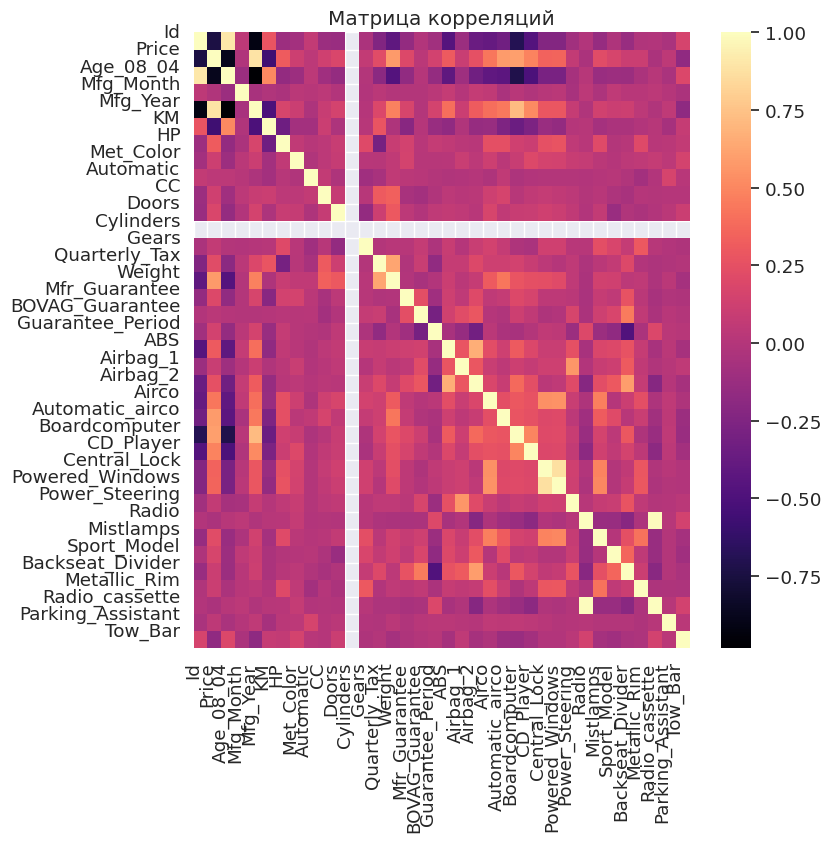

In [18]:

fig,ax=plt.subplots(figsize=(8,8))
sns.heatmap(corr,cmap='magma',annot=False,fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций")
plt.show()

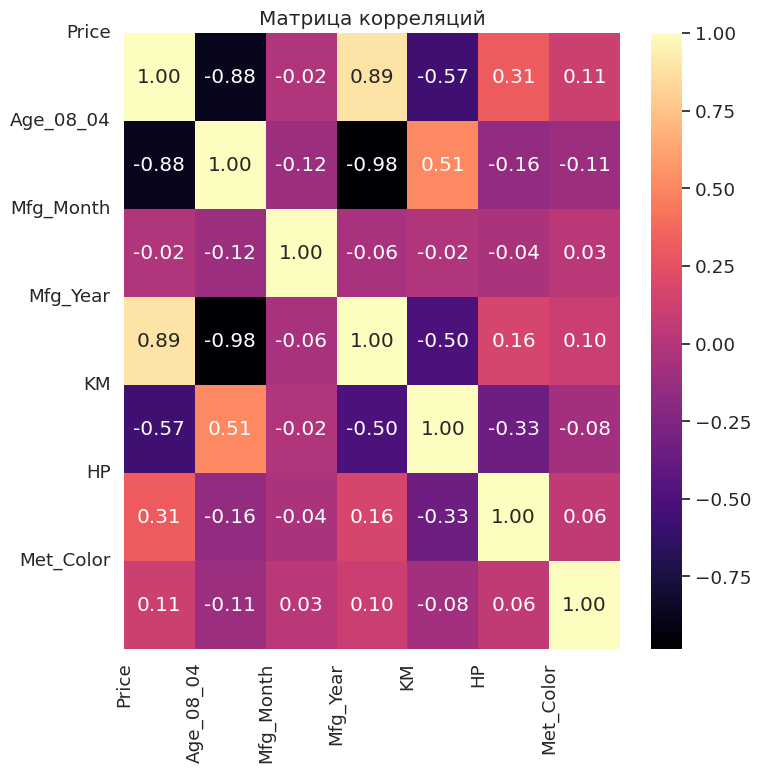

In [19]:
coll=df.iloc[:,1:10]
corr2=coll.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr2, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr2.columns)), corr2.columns)
plt.yticks(range(len(corr2.columns)), corr2.columns)
plt.title("Матрица корреляций")
plt.show()

<Axes: xlabel='Price', ylabel='Mfg_Year'>

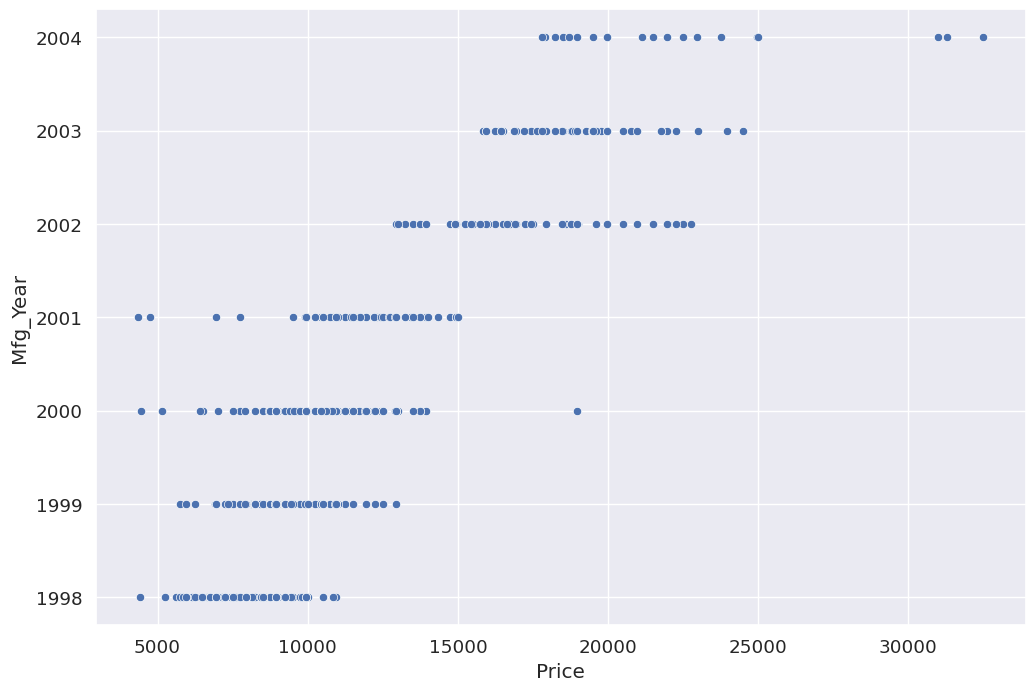

In [20]:
sns.scatterplot(data=df, x="Price", y="Mfg_Year")

<Axes: xlabel='Price', ylabel='HP'>

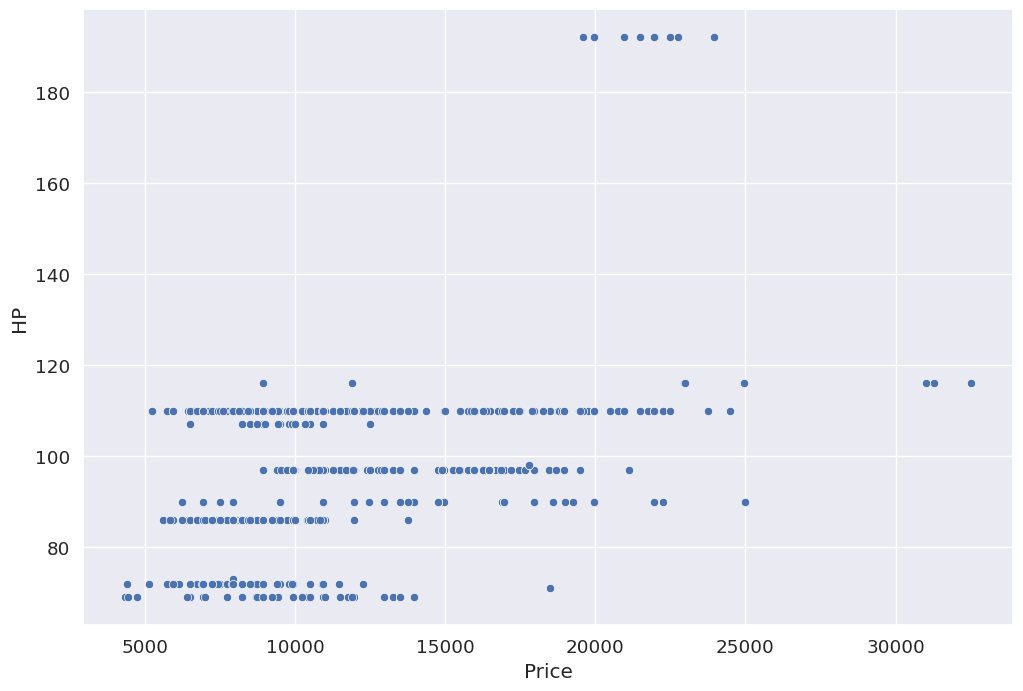

In [21]:
sns.scatterplot(data=df,y="HP",x="Price")

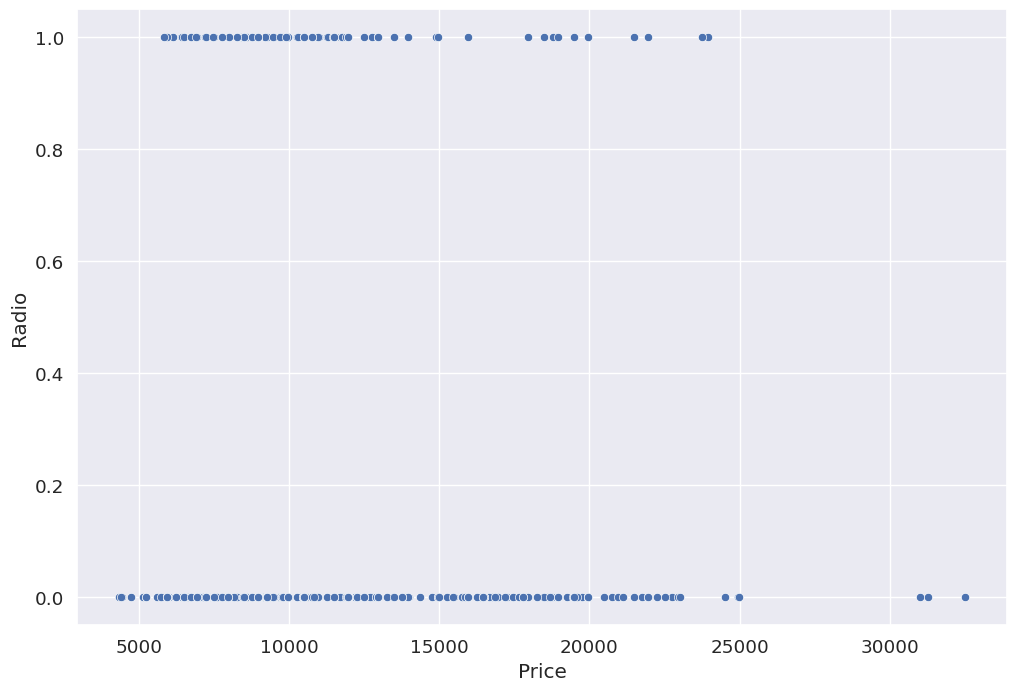

In [22]:
sns.scatterplot(
    data=df,
    x="Price",
    y="Radio"
)

plt.show()

Cylinders можно удалять (существуют толь 4 целиндровые )

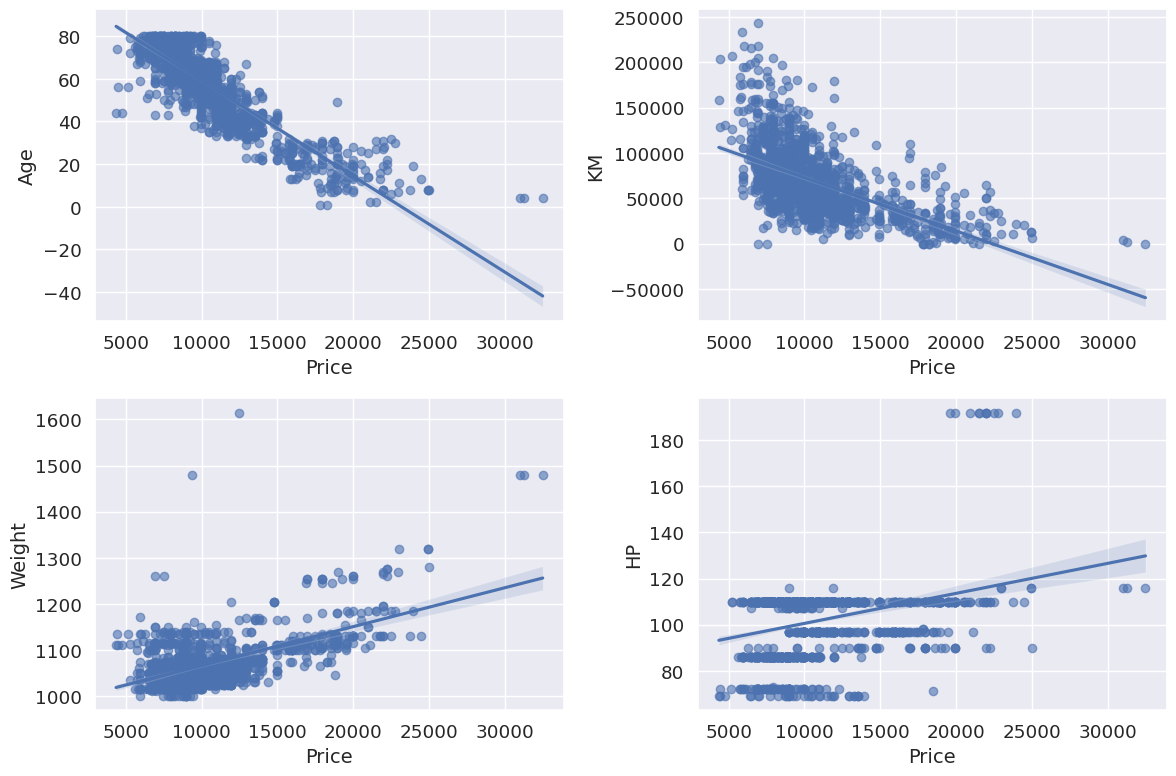

In [23]:
f, axes = plt.subplots(2, 2, figsize=(12,8))

sns.regplot(x='Price', y='Age_08_04', data=df, scatter_kws={'alpha':0.6}, ax=axes[0,0])
axes[0,0].set_xlabel('Price', fontsize=14)
axes[0,0].set_ylabel('Age', fontsize=14)

sns.regplot(x='Price', y='KM', data=df, scatter_kws={'alpha':0.6}, ax=axes[0,1])
axes[0,1].set_xlabel('Price', fontsize=14)
axes[0,1].set_ylabel('KM', fontsize=14)

sns.regplot(x='Price', y='Weight', data=df, scatter_kws={'alpha':0.6}, ax=axes[1,0])
axes[1,0].set_xlabel('Price', fontsize=14)
axes[1,0].set_ylabel('Weight', fontsize=14)

sns.regplot(x='Price', y='HP', data=df, scatter_kws={'alpha':0.6}, ax=axes[1,1])
axes[1,1].set_xlabel('Price', fontsize=14)
axes[1,1].set_ylabel('HP', fontsize=14)

plt.tight_layout()
plt.show()

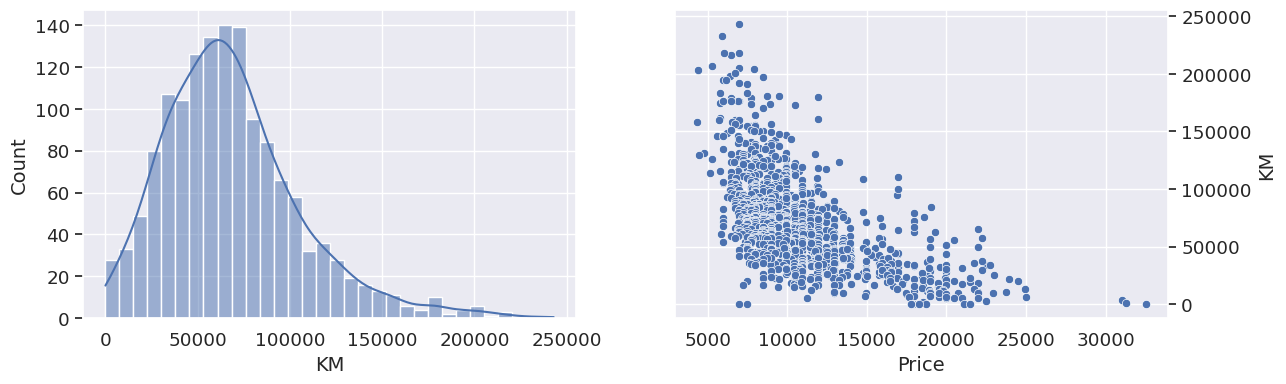

In [24]:
f, axes = plt.subplots(1,2,figsize=(14,4))

sns.histplot(df['KM'], ax = axes[0],kde=True)
axes[0].set_xlabel('KM', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.scatterplot(x = 'Price', y = 'KM', data = df, ax = axes[1])
axes[1].set_xlabel('Price', fontsize=14)
axes[1].set_ylabel('KM', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.show()

/tmp/ipykernel_57435/1321125972.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['Color'], ax = axes[0], palette="pastel")


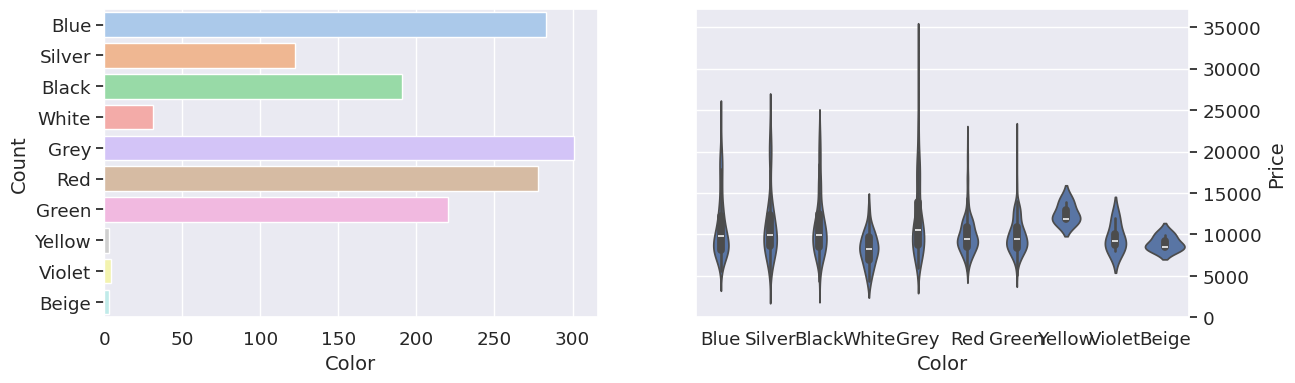

In [25]:
fuel_list= Counter(df['Color'])
labels = fuel_list.keys()
sizes = fuel_list.values()

f, axes = plt.subplots(1,2,figsize=(14,4))

sns.countplot(df['Color'], ax = axes[0], palette="pastel")
axes[0].set_xlabel('Color', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.violinplot(x = 'Color', y = 'Price', data = df, ax = axes[1])
axes[1].set_xlabel('Color', fontsize=14)
axes[1].set_ylabel('Price', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.show()

/tmp/ipykernel_57435/3221958374.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['Fuel_Type'], ax = axes[0], palette="Set1")


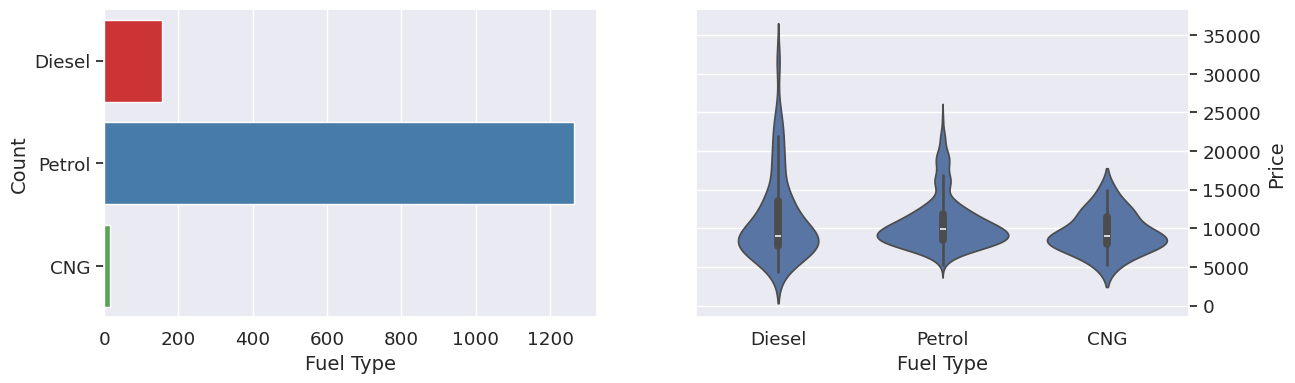

In [26]:
fuel_list= Counter(df['Fuel_Type'])
labels = fuel_list.keys()
sizes = fuel_list.values()

f, axes = plt.subplots(1,2,figsize=(14,4))

sns.countplot(df['Fuel_Type'], ax = axes[0], palette="Set1")
axes[0].set_xlabel('Fuel Type', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)
axes[0].yaxis.tick_left()

sns.violinplot(x = 'Fuel_Type', y = 'Price', data = df, ax = axes[1])
axes[1].set_xlabel('Fuel Type', fontsize=14)
axes[1].set_ylabel('Price', fontsize=14)
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

plt.show()

Основой предобработки стала корреляция данных. Смогли определить главные и вторичные признаки. Оценили расспределение данных и их линейные зависимости

#3. Работа с признаками (Feature Engineering)& Разделение выборки

## Подготовка данных

In [27]:
df_encoded = pd.get_dummies(
    df.drop(columns=['Model']),
    drop_first=True
)

df_encoder = pd.concat([df_encoded, df['Model']], axis=1)

X=df_encoder.drop('Price',axis=1)
y=df_encoder['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Размер тренировочной выборки признаков: {X_train.shape}")
print(f"Размер тестовой выборки признаков: {X_test.shape}")
print(f"Размер тренировочной выборки целевой переменной: {y_train.shape}")
print(f"Размер тестовой выборки целевой переменной: {y_test.shape}")

print("TRAIN columns:", X_train.columns)
print("TEST columns:", X_test.columns)

Размер тренировочной выборки признаков: (1077, 47)
Размер тестовой выборки признаков: (359, 47)
Размер тренировочной выборки целевой переменной: (1077,)
Размер тестовой выборки целевой переменной: (359,)
TRAIN columns: Index(['Id', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'Met_Color',
       'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax',
       'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS',
       'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer',
       'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering',
       'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
       'Radio_cassette', 'Parking_Assistant', 'Tow_Bar', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Color_Black', 'Color_Blue', 'Color_Green',
       'Color_Grey', 'Color_Red', 'Color_Silver', 'Color_Violet',
       'Color_White', 'Color_Yellow', 'Model'],
      dtype='object')
TEST columns: Index(['Id', 'Age_08_04'

In [28]:
print(set(df['Fuel_Type']))
print(set(df['Color']))
df_encoder.head()

{'CNG', 'Diesel', 'Petrol'}
{'Grey', 'White', 'Black', 'Silver', 'Violet', 'Yellow', 'Beige', 'Blue', 'Red', 'Green'}


,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Fuel_Type_Diesel,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Model
0,1,13500,23,10,2002,46986,90,1,0,2000,3,4,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0,True,False,False,True,False,False,False,False,False,False,False,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors
1,2,13750,23,10,2002,72937,90,1,0,2000,3,4,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0,True,False,False,False,False,False,False,True,False,False,False,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors
2,3,13950,24,9,2002,41711,90,1,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,True,False,False,True,False,False,False,False,False,False,False,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors
3,4,14950,26,7,2002,48000,90,0,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,True,False,True,False,False,False,False,False,False,False,False,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors
4,5,13750,30,3,2002,38500,90,0,0,2000,3,4,5,210,1170,1,1,3,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0,True,False,True,False,False,False,False,False,False,False,False,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors


Разделила на большую часть для тренировочного теста и меньшей части тестового. С помощью такого разделения мы сможем потом проверить нашу модель на тестовых данных, на ее правильность обучения

In [29]:
print("Начинаем предобработку данных с Target Encoding для 'Model'...")
df_train_for_target=pd.DataFrame({
    'Model':X_train['Model'],
    'Price':y_train
})#Соеденили обратно
model_mean=df_train_for_target.groupby('Model')['Price'].mean()

#Возвращаемся в train
X_train['Model_target_Encoded']=X_train['Model'].map(model_mean)
glob_mean_price=y_train.mean()

#Вернем в тест
X_test['Model_target_Encoded']=X_test['Model'].map(model_mean).fillna(glob_mean_price)

X_train = X_train.drop('Model', axis=1)
X_test = X_test.drop('Model', axis=1)
print("Target Encoding успешно применен к 'Model'.")

print(f"Размер тренировочной выборки признаков после кодирования: {X_train.shape}")
print(f"Размер тестовой выборки признаков после кодирования: {X_test.shape}")
print(f"Размер тренировочной выборки целевой переменной: {y_train.shape}")
print(f"Размер тестовой выборки целевой переменной: {y_test.shape}")

print(X_train['Model_target_Encoded'].isna().sum())
print(X_test['Model_target_Encoded'].isna().sum())
X_test.head()

Начинаем предобработку данных с Target Encoding для 'Model'...
Target Encoding успешно применен к 'Model'.
Размер тренировочной выборки признаков после кодирования: (1077, 47)
Размер тестовой выборки признаков после кодирования: (359, 47)
Размер тренировочной выборки целевой переменной: (1077,)
Размер тестовой выборки целевой переменной: (359,)
0
0


,Id,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Fuel_Type_Diesel,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Model_target_Encoded
594,598,50,7,2000,22500,97,1,0,1400,3,4,5,69,1025,0,1,3,1,1,1,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,False,True,False,False,True,False,False,False,False,False,False,10311.621622
754,758,68,1,1999,80426,110,1,0,1600,3,4,5,85,1055,1,1,3,1,1,1,0,0,0,0,1,1,1,0,1,0,1,0,0,0,0,False,True,False,False,True,False,False,False,False,False,False,8650.833333
630,634,59,10,1999,130000,72,1,0,2000,4,4,5,185,1135,0,1,3,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,True,False,False,False,False,True,False,False,False,False,False,10758.266481
1259,1266,71,10,1998,76000,110,1,0,1600,5,4,5,85,1070,0,1,3,1,1,1,1,0,0,0,1,1,1,0,0,0,1,0,0,0,1,False,True,False,True,False,False,False,False,False,False,False,8819.901961
903,907,65,4,1999,59000,110,0,0,1600,5,4,5,19,1075,0,0,12,1,1,0,1,0,0,0,1,0,1,1,0,0,0,0,1,0,1,False,True,False,False,True,False,False,False,False,False,False,10758.266481


In [30]:
print("TRAIN columns:", X_train.columns)
print("TEST columns:", X_test.columns)

TRAIN columns: Index(['Id', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'Met_Color',
       'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax',
       'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS',
       'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer',
       'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering',
       'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
       'Radio_cassette', 'Parking_Assistant', 'Tow_Bar', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Color_Black', 'Color_Blue', 'Color_Green',
       'Color_Grey', 'Color_Red', 'Color_Silver', 'Color_Violet',
       'Color_White', 'Color_Yellow', 'Model_target_Encoded'],
      dtype='object')
TEST columns: Index(['Id', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'Met_Color',
       'Automatic', 'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax',
       'Weight', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee

In [31]:
#Чистим от ненужных признаков
train_df=X_train.copy()
train_df['Price']=y_train

corr_matrix=train_df.corr(numeric_only=True)
target_corr=corr_matrix['Price'].abs()

treshold = 0.05 # можно менять на больший выброс
low_corr_cols = target_corr[target_corr <= treshold].index.tolist()


#Убираем сам таргет Price

low_corr_cols=[col for col in low_corr_cols if col != 'Price']

cols_to_drop = list(set(low_corr_cols + ['Cylinders']))# не нужен одни значения Nan

print(f"Признаки с корреляцией < {treshold} по модулю: {cols_to_drop}")

print(f"Удаляем признаки: {cols_to_drop}")

X_train_e1 = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test_e1 = X_test.drop(columns=cols_to_drop, errors='ignore')

print("TRAIN columns:", X_train_e1.columns)
print("TEST columns:", X_test_e1.columns)

Признаки с корреляцией < 0.05 по модулю: ['Mfg_Month', 'Radio_cassette', 'Color_Violet', 'Color_Yellow', 'Color_Blue', 'Cylinders', 'Automatic', 'Parking_Assistant', 'Color_Silver', 'Fuel_Type_Petrol', 'Color_Black', 'Radio', 'BOVAG_Guarantee', 'Fuel_Type_Diesel']
Удаляем признаки: ['Mfg_Month', 'Radio_cassette', 'Color_Violet', 'Color_Yellow', 'Color_Blue', 'Cylinders', 'Automatic', 'Parking_Assistant', 'Color_Silver', 'Fuel_Type_Petrol', 'Color_Black', 'Radio', 'BOVAG_Guarantee', 'Fuel_Type_Diesel']
TRAIN columns: Index(['Id', 'Age_08_04', 'Mfg_Year', 'KM', 'HP', 'Met_Color', 'CC', 'Doors',
       'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee', 'Guarantee_Period',
       'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco',
       'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows',
       'Power_Steering', 'Mistlamps', 'Sport_Model', 'Backseat_Divider',
       'Metallic_Rim', 'Tow_Bar', 'Color_Green', 'Color_Grey', 'Color_Red',
       'Color_White', 'Model_targ

#4. Обучение моделей

Обучите базовую линейную регрессию, а также модели с регуляризацией (например, Ridge и/от Lasso).

In [32]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
]

reg_linear = Pipeline(linear_steps)

param_grid = {'poly__degree': [1, 2]}

regressor_linear_grid = GridSearchCV(
    reg_linear,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

regressor_linear_grid.fit(X_train_e1, y_train)
print(regressor_linear_grid.best_params_)

y_pred_linear_train = regressor_linear_grid.predict(X_train_e1)
y_pred_linear_test = regressor_linear_grid.predict(X_test_e1)

#Метрики
r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
best_model = regressor_linear_grid.best_estimator_

cv_linear = cross_val_score(
    estimator=best_model,
    X=X_train_e1,
    y=y_train,
    cv=10
)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

{'poly__degree': 1}
Linear Regression Results:
CV Mean:  0.9360352888062213
R2_score (train):  0.9432648566046304
R2_score (test):  0.8112400033699881
RMSE:  1636.6648846466308
MAPE:  0.09326063785135208


### Метрики регрессии

Пусть:
*   $y_i$ — истинное значение целевой переменной для $i$-го объекта.
*   $\hat{y}_i$ — предсказанное значение модели для $i$-го объекта.
*   $n$ — количество объектов в выборке.

---

#### 1. MSE (Mean Squared Error)
Среднеквадратичная ошибка. Штрафует за большие отклонения, возводя ошибку в квадрат.

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

---

#### 2. RMSE (Root Mean Squared Error)
Корень из среднеквадратичной ошибки. Имеет ту же размерность, что и целевая переменная.

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

---

#### 3. MAPE (Mean Absolute Percentage Error)
Средняя абсолютная процентная ошибка. Показывает ошибку в процентах относительно истинных значений.

$$
MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
$$

---

#### 4. R² (Коэффициент детерминации)
Показывает долю дисперсии зависимой переменной, объясняемую рассматриваемой моделью. Максимальное значение — 1. Может быть отрицательным (модель хуже, чем простое среднее).

Обозначим среднее значение истинных значений как $\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$.

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

## Анализ остатков (ошибок моделей )

Остаток=реальное значение- предсказание

По теореме Гаусса-Маркова остатки должны иметь нормальное распределение и не зависеть от прогнозируемых значений (гомоскедастичность).

In [33]:
y_train.shape

(1077,)

In [34]:
residuals= (y_train.ravel() - y_pred_linear_train).ravel()
print(residuals)

[  112.88837333   339.72916435   -25.79800973 ...  -234.9459987
   164.34026724 -1056.7693841 ]


/tmp/ipykernel_57435/120941274.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  residuals= (y_train.ravel() - y_pred_linear_train).ravel()


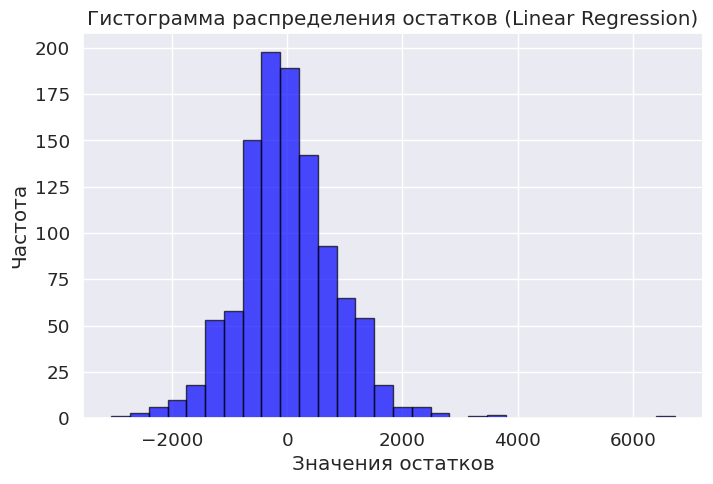

Статистика Колмогорова-Смирнова: 0.0548, P-значение: 2.9934e-03
Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).


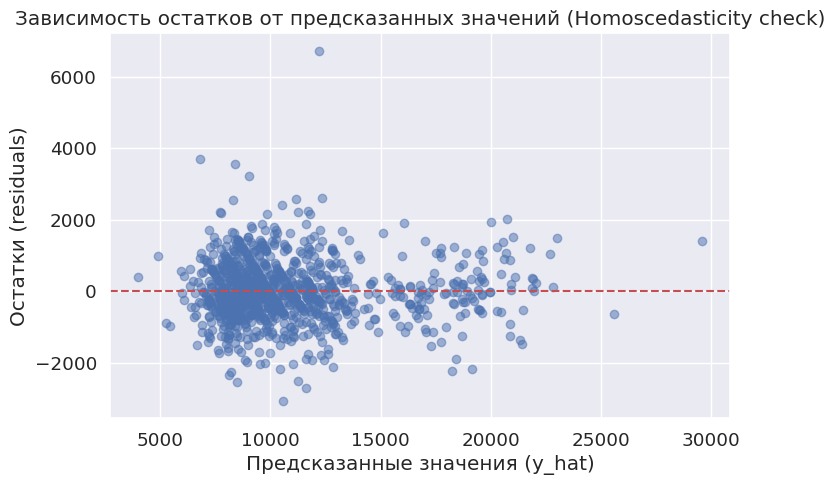

In [35]:
def analyze_residuals(residuals, y_pred):
  # 1. Гистограмма остатков
  plt.figure(figsize=(8, 5))
  plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
  plt.title('Гистограмма распределения остатков (Linear Regression)')
  plt.xlabel('Значения остатков')
  plt.ylabel('Частота')
  plt.show()

  # 2. Проверка гипотезы о нормальности остатков (Критерий Колмогорова-Смирнова)
  residuals_mean = np.mean(residuals)
  residuals_std = np.std(residuals)
  theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

  statistic, p_value = kstest(residuals, theoretical_distribution.cdf)
  print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

  alpha = 0.05
  if p_value < alpha:
      print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
  else:
      print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")

  # 3. Диаграмма рассеяния: Остатки vs Прогнозы
  plt.figure(figsize=(8,5))
  plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
  plt.xlabel("Предсказанные значения (y_hat)")
  plt.ylabel("Остатки (residuals)")
  plt.show()
analyze_residuals(residuals, y_pred_linear_train)

Есть поле для улучшений стоит пересмотреть признаки и их обработку

 ## 5. Регуляризация с подбором гиперпараметров (GridSearchCV)

In [36]:
ridge_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge())
]
ridge_pipe = Pipeline(ridge_steps)

ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2000.0]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')#Поиск по сетке
#Важно подбирать гиперпараметры
ridge_grid.fit(X_train_e1, y_train)

best_ridge = ridge_grid.best_estimator_
print(f"Лучший параметр alpha для Ridge: {ridge_grid.best_params_['model__alpha']}")

y_pred_ridge_train = best_ridge.predict(X_train_e1)
y_pred_ridge_test = best_ridge.predict(X_test_e1)

r2_score_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_score_ridge_test = r2_score(y_test, y_pred_ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge_test)
cv_ridge = cross_val_score(estimator=best_ridge, X=X_train_e1, y=y_train, cv=10).mean()

print("Ridge Regression Results:")
print(f"R2 Score (train): {r2_score_ridge_train:.4f}")
print(f"R2 Score (test): {r2_score_ridge_test:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"MAPE: {mape_ridge:.4f}")

Лучший параметр alpha для Ridge: 100.0
Ridge Regression Results:
R2 Score (train): 0.9646
R2 Score (test): 0.8361
RMSE: 1524.90
MAPE: 0.0906


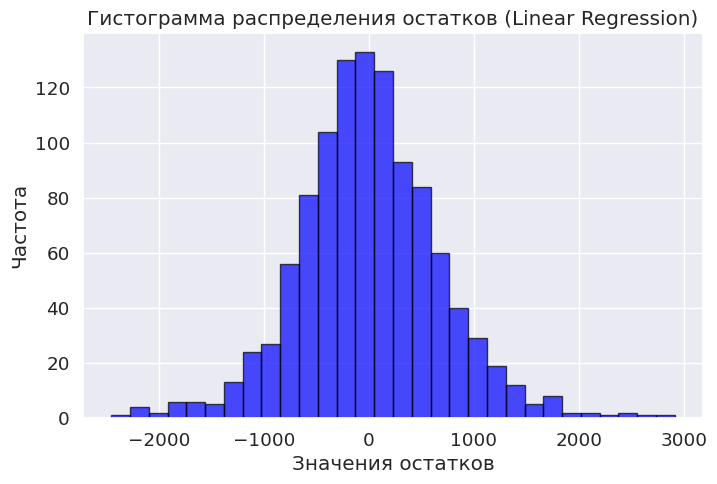

Статистика Колмогорова-Смирнова: 0.0349, P-значение: 1.4142e-01
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


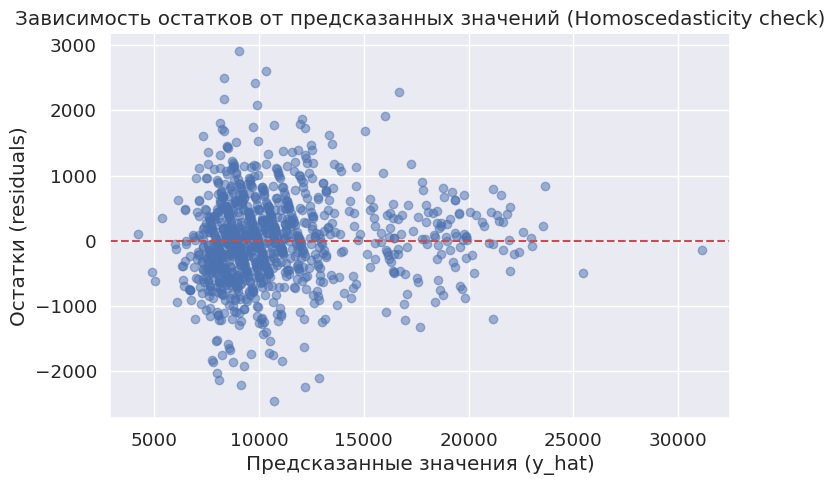

In [37]:
residuals_ridge = (y_train - y_pred_ridge_train)
analyze_residuals(residuals_ridge, y_pred_ridge_train)

In [38]:
lasso_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Lasso(max_iter=10000))
]
lasso_pipe = Pipeline(lasso_steps)

lasso_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_e1, y_train)

best_lasso = lasso_grid.best_estimator_
print(f"Лучший параметр alpha для Lasso: {lasso_grid.best_params_['model__alpha']}")

y_pred_lasso_train = best_lasso.predict(X_train_e1)
y_pred_lasso_test = best_lasso.predict(X_test_e1)

r2_score_lasso_train = r2_score(y_train, y_pred_lasso_train)
r2_score_lasso_test = r2_score(y_test, y_pred_lasso_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso_test)
cv_lasso = cross_val_score(estimator=best_lasso, X=X_train_e1, y=y_train, cv=10).mean()

print("Lasso Regression Results:")
print(f"R2 Score (train): {r2_score_lasso_train:.4f}")
print(f"R2 Score (test): {r2_score_lasso_test:.4f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAPE: {mape_lasso:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.773e+07, tolerance: 1.161e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.131e+07, tolerance: 1.029e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.018e+08, tolerance: 1.100e

Лучший параметр alpha для Lasso: 100.0
Lasso Regression Results:
R2 Score (train): 0.9391
R2 Score (test): 0.7913
RMSE: 1721.03
MAPE: 0.0966


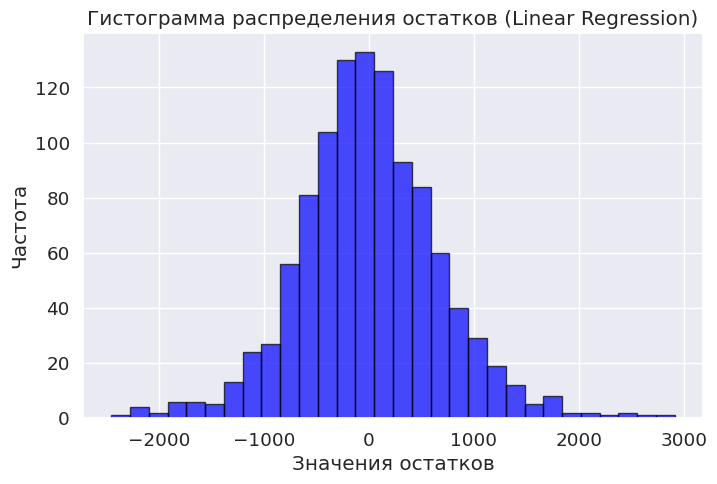

Статистика Колмогорова-Смирнова: 0.0349, P-значение: 1.4142e-01
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


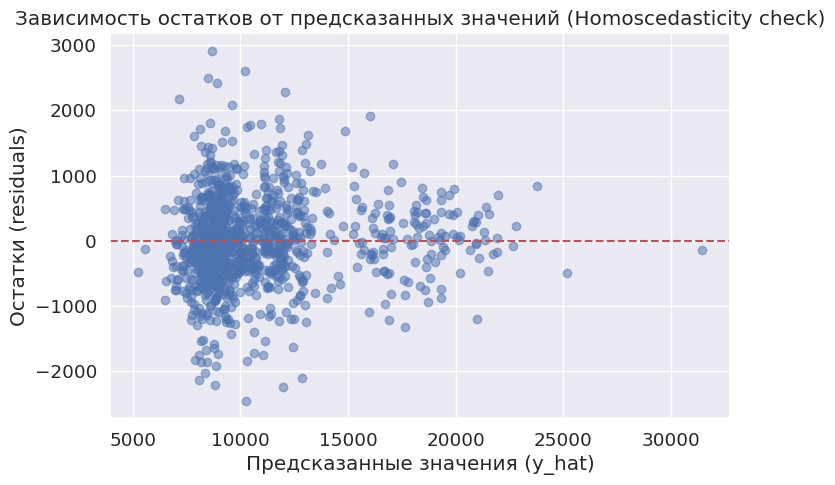

In [39]:
residuals_lasso = (y_train- y_pred_lasso_train)
analyze_residuals(residuals_ridge, y_pred_lasso_train)

 ## 6. МНК vs Градиентный спуск
 Продемонстрируем, что модель, обученная ручным градиентным спуском, сходится к тем же результатам (или очень близким), что и аналитическое решение МНК (`LinearRegression`). Для GD обязательна стандартизация данных!

In [40]:
def add_const(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def gradient_descent(X, y, lr=0.01, iterations=5000):
    X_c = add_const(X)
    n, m = X_c.shape
    w = np.zeros(m)
    for k in range(iterations):
        grad = 2 / n * X_c.T @ (X_c @ w - y.ravel())
        w -= lr * grad
    return w


# Для ГС обязательно стандартизируем данные
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_e1)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
X_test_scaled = scaler_X.transform(X_test_e1)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

# 1. Обучаем ручной Градиентный Спуск
w_gd = gradient_descent(X_train_scaled, y_train_scaled, lr=0.01, iterations=10000)
# Предсказание GD
y_pred_gd_scaled = add_const(X_test_scaled) @ w_gd
y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled.reshape(-1,1))

# 2. Обучаем OLS (МНК) из sklearn на тех же масштабированных данных
lr_scaled = LinearRegression(fit_intercept=True)
lr_scaled.fit(X_train_scaled, y_train_scaled.ravel())
w_ols = np.insert(lr_scaled.coef_, 0, lr_scaled.intercept_) # добавляем bias для красоты
y_pred_ols_scaled = lr_scaled.predict(X_test_scaled)
y_pred_ols = scaler_y.inverse_transform(y_pred_ols_scaled.reshape(-1,1))

# Сравнение весов и результатов
print("Сравнение весов (w0, w1...):")
print(f"Градиентный спуск: \n{w_gd} ...") # Выводим первые 5 для компактности
print(f"Аналитический МНК: \n{w_ols} ...")

rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd))
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))

print(f"\nRMSE Градиентный спуск: {rmse_gd:.4f}")
print(f"RMSE МНК (LinearRegression): {rmse_ols:.4f}")
# Почему методы выдают примерно похожие результаты погуглить

Сравнение весов (w0, w1...):
Градиентный спуск: 
[-1.43921119e-14 -3.56048846e-02 -1.53754590e-03  2.45744829e-01
 -1.40826081e-01  1.20960023e-02 -3.46566968e-03 -5.15462655e-03
  2.87209330e-03  1.87499011e-03  3.93612938e-02  5.20919388e-02
  3.57524223e-02  7.65612999e-03 -1.98598931e-02  3.57357962e-03
  1.57226731e-02  3.27521939e-02  4.62491134e-02 -8.32678657e-02
  1.38247463e-02 -2.21753276e-02  3.00583744e-02  6.02867329e-03
 -4.20358423e-03 -3.74704005e-03 -6.99827126e-03  1.41530403e-02
 -1.23491838e-02 -4.05518727e-03  4.69003096e-03 -1.56769549e-03
 -2.17727096e-02  5.92213494e-01] ...
Аналитический МНК: 
[-1.48300608e-14 -3.39219533e-02  3.78524886e-03  2.53278266e-01
 -1.40432592e-01  1.22622254e-02 -3.41579654e-03 -5.10029969e-03
  2.88806472e-03  1.89662564e-03  3.94598707e-02  5.20633218e-02
  3.57474554e-02  7.68735040e-03 -1.96473581e-02  3.63519427e-03
  1.57279953e-02  3.28295764e-02  4.63094024e-02 -8.31461863e-02
  1.37439073e-02 -2.23071762e-02  3.01989669e-02

 Видим, что веса и ошибки у МНК и градиентного спуска идентичны (с точностью до погрешности итераций).

 ## 7. Итоговая таблица результатов

In [41]:
models = [
    ('Linear Regression (Base)', rmse_linear, mape_linear, r2_score_linear_test),
    ('Ridge (GridSearchCV)', rmse_ridge, mape_ridge, r2_score_ridge_test),
    ('Lasso (GridSearchCV)', rmse_lasso, mape_lasso, r2_score_lasso_test)
]

predict_df = pd.DataFrame(data=models, columns=['Model', 'RMSE', 'MAPE', 'R2_Score(test)'])
display(predict_df)

,Model,RMSE,MAPE,R2_Score(test)
0,Linear Regression (Base),1636.664885,0.093261,0.811240
1,Ridge (GridSearchCV),1524.896665,0.090560,0.836141
2,Lasso (GridSearchCV),1721.027735,0.096638,0.791279


/tmp/ipykernel_57435/948354018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis')
/tmp/ipykernel_57435/948354018.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAPE', y='Model', data=predict_df.sort_values('MAPE'), ax=axes[1], palette='magma')
/tmp/ipykernel_57435/948354018.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[2], palette='rocket

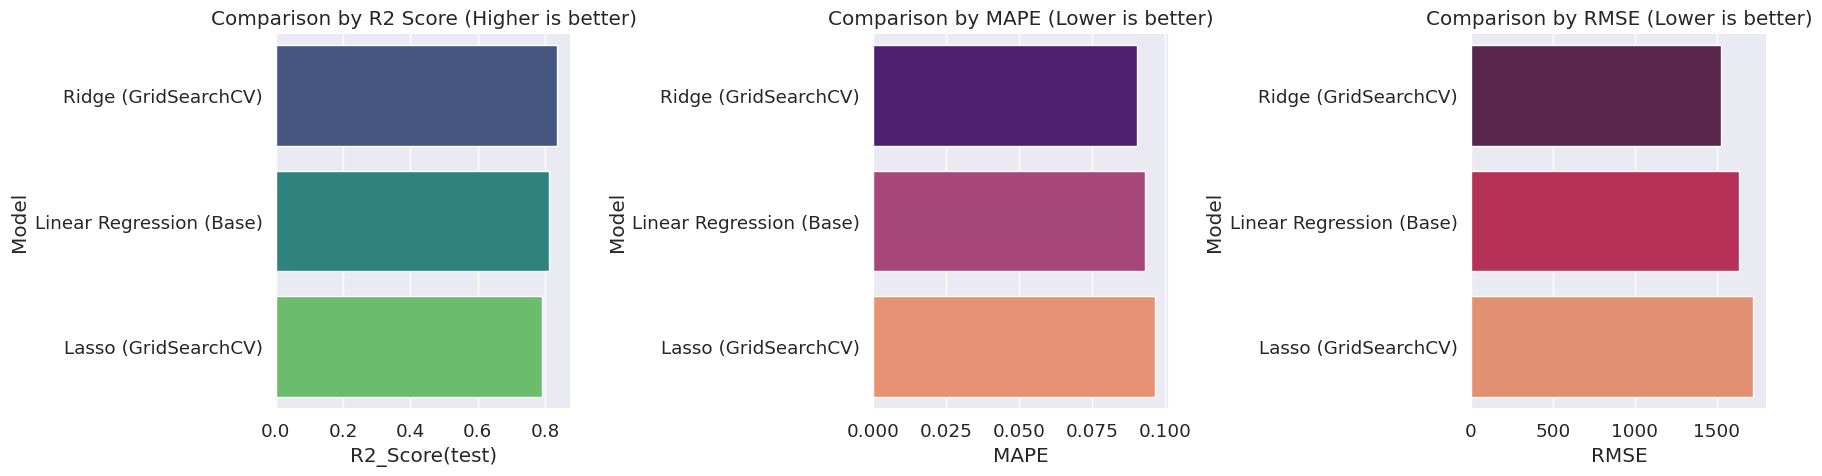

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Comparison by R2 Score (Higher is better)')

sns.barplot(x='MAPE', y='Model', data=predict_df.sort_values('MAPE'), ax=axes[1], palette='magma')
axes[1].set_title('Comparison by MAPE (Lower is better)')

sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[2], palette='rocket')
axes[2].set_title('Comparison by RMSE (Lower is better)')

plt.tight_layout()
plt.show()

Использовала все метри, по итогу, более явной является R2.
Метрики считала на y_train,y_test.
Ridge показала более стабильный результат.
При анализе метрик значения на тесте и на трейне не сильно различны, ошибка меньше 10%-15% что вполне хорошо.Поэтому модель не сильно переобучилась.

Но под конец моделям немного не хватило признаков, поэтому стоит пересмотреть ход обработки и обучения(((